<a href="https://colab.research.google.com/github/srujannayak45/DL-ASSIGNMENT/blob/main/WEEK_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9460 - loss: 0.1772 - val_accuracy: 0.9843 - val_loss: 0.0549
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9814 - loss: 0.0657 - val_accuracy: 0.9868 - val_loss: 0.0458
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9864 - loss: 0.0462 - val_accuracy: 0.9877 - val_loss: 0.0430
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9892 - loss: 0.0381 - val_accuracy: 0.9872 - val_loss: 0.0412
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9901 - loss: 0.0320 - val_accuracy: 0.9872 - val_loss: 0.0522
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0309 - val_accuracy: 0.9895 - val_loss: 0.0442
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9933 - loss: 0.0240 - val_accuracy: 0.9889 - val_loss: 0.0524
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9926 - loss: 0.0243 - val_accuracy: 0

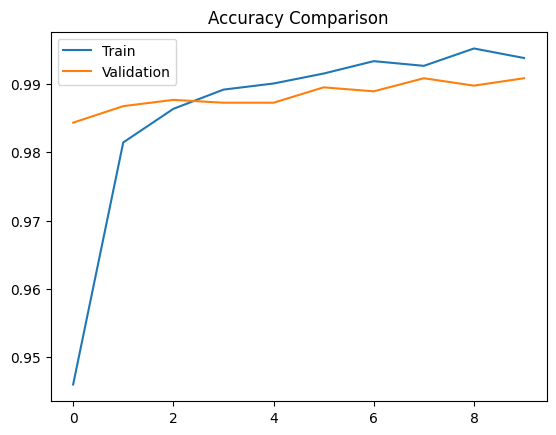

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# One-hot encode
y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test,10)

# -----------------------------
# MODIFIED LENET MODEL
# -----------------------------
model = models.Sequential([

    # Conv Block 1
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Conv Block 3
    layers.Conv2D(128,(3,3),activation='relu'),

    # Flatten
    layers.Flatten(),

    # Dense
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    # Output
    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Modified LeNet Accuracy:", test_acc)

# Plot
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8956 - loss: 0.3584
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9585 - loss: 0.1338
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9735 - loss: 0.0870
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step

🔹 Layer: conv2d_3
Shape: (1, 24, 24, 6)


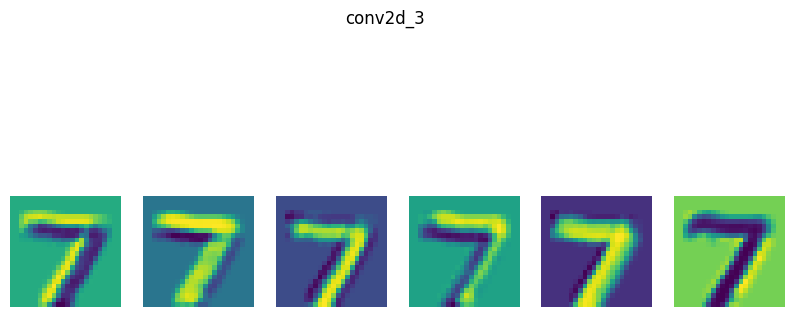


🔹 Layer: average_pooling2d
Shape: (1, 12, 12, 6)


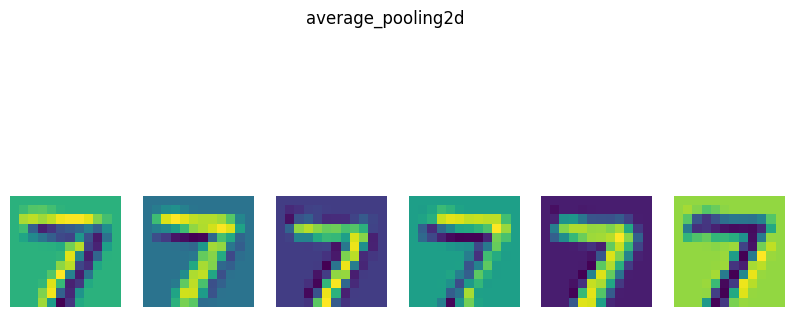


🔹 Layer: conv2d_4
Shape: (1, 8, 8, 16)


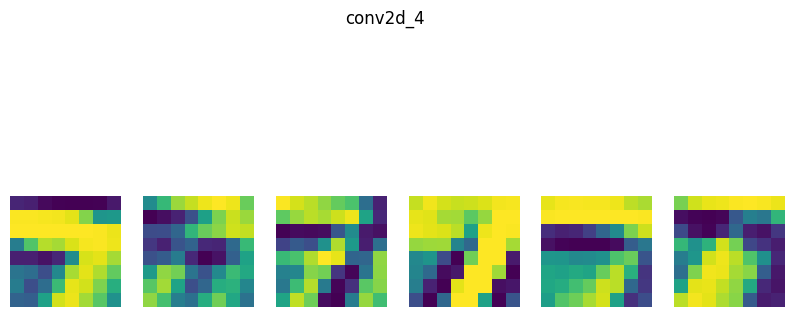


🔹 Layer: average_pooling2d_1
Shape: (1, 4, 4, 16)


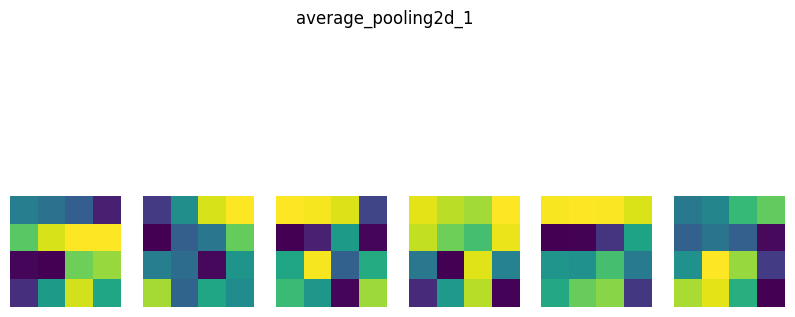


🔹 Layer: flatten_1
Shape: (1, 256)

🔹 Layer: dense_2
Shape: (1, 120)

🔹 Layer: dense_3
Shape: (1, 84)

🔹 Layer: dense_4
Shape: (1, 10)


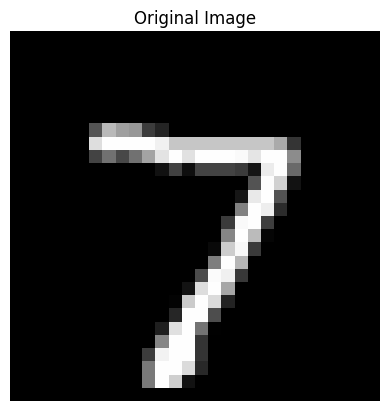

In [2]:
import tensorflow as tf
from tensorflow.keras import models
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Load MNIST
# -----------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# -----------------------------
# 2. Build LeNet Model
# -----------------------------
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),

    tf.keras.layers.Conv2D(6,(5,5),activation='tanh'),
    tf.keras.layers.AveragePooling2D((2,2)),
    tf.keras.layers.Conv2D(16,(5,5),activation='tanh'),
    tf.keras.layers.AveragePooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120,activation='tanh'),
    tf.keras.layers.Dense(84,activation='tanh'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train quickly
model.fit(x_train, y_train, epochs=3, batch_size=128)

# -----------------------------
# 3. Create Activation Model (ONLY ONCE)
# -----------------------------
layer_names = [layer.name for layer in model.layers]

activation_input = tf.keras.Input(shape=(28, 28, 1))
x = activation_input

activation_outputs_tensors = []
for layer in model.layers:
    x = layer(x)
    activation_outputs_tensors.append(x)

activation_model = models.Model(
    inputs=activation_input, # Use the new Input tensor
    outputs=activation_outputs_tensors # Use the collected outputs
)

# -----------------------------
# 4. Select One Image
# -----------------------------
img = x_test[0:1] # Selects the first image as a batch of 1

# -----------------------------
# 5. Get Outputs
# -----------------------------
activations = activation_model.predict(img)

# -----------------------------
# 6. Visualize Feature Maps
# -----------------------------

for layer_name, layer_activation in zip(layer_names, activations):

    print(f"\n🔹 Layer: {layer_name}")
    print("Shape:", layer_activation.shape)

    if len(layer_activation.shape) == 4:  # Conv/Pooling layers only
        num_filters = layer_activation.shape[-1]

        plt.figure(figsize=(10,5))

        for i in range(min(num_filters, 6)):
            plt.subplot(1,6,i+1)
            plt.imshow(layer_activation[0,:,:,i], cmap='viridis')
            plt.axis('off')

        plt.suptitle(layer_name)
        plt.show()

# -----------------------------
# 7. Show Original Image
# -----------------------------
plt.imshow(x_test[0], cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8924 - loss: 0.3653
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9589 - loss: 0.1348
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9736 - loss: 0.0878
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


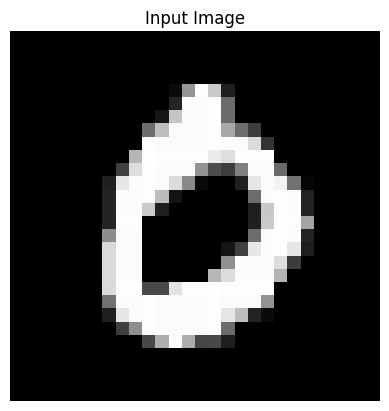


🔹 Layer: C1
Shape: (1, 24, 24, 6)


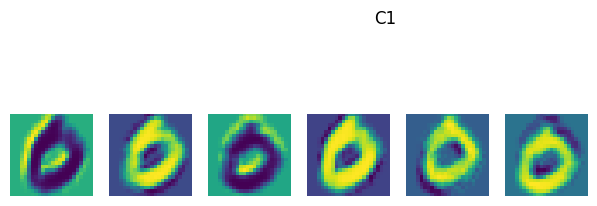


🔹 Layer: S2
Shape: (1, 12, 12, 6)


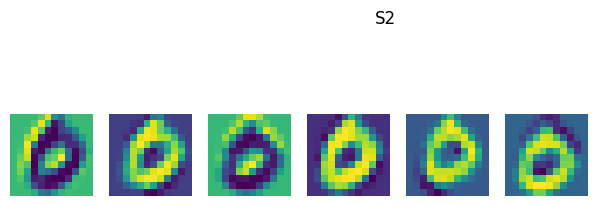


🔹 Layer: C3
Shape: (1, 8, 8, 16)


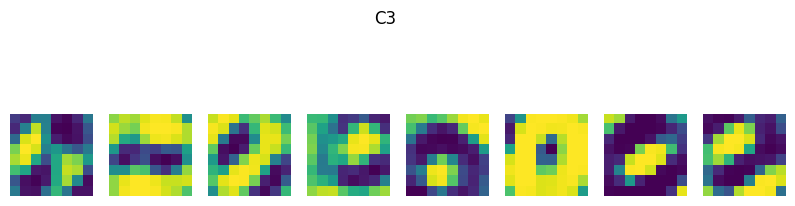


🔹 Layer: S4
Shape: (1, 4, 4, 16)


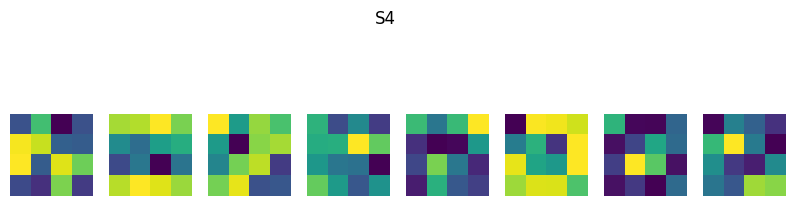


🔹 Layer: Flatten
Shape: (1, 256)


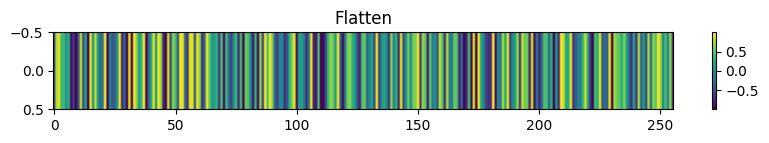


🔹 Layer: C5
Shape: (1, 120)


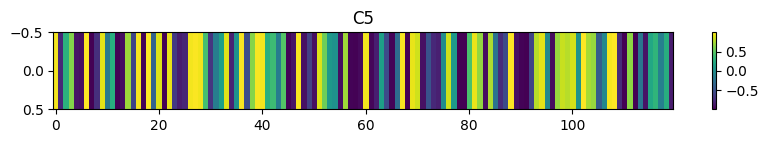


🔹 Layer: F6
Shape: (1, 84)


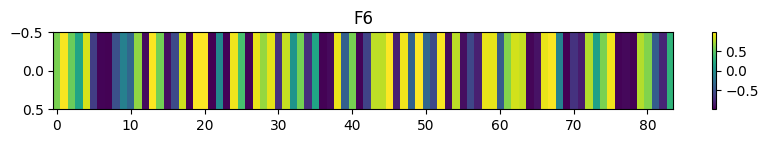


🔹 Layer: Output
Shape: (1, 10)


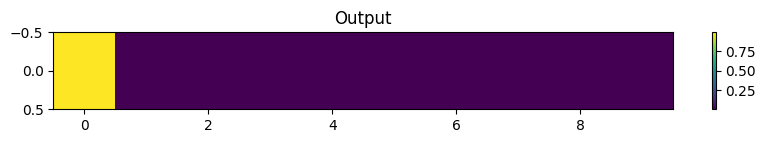

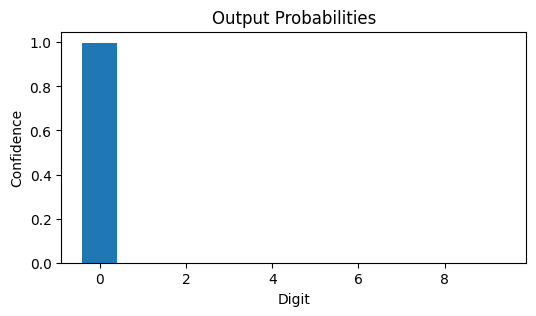

Predicted Digit: 0


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load Dataset
# -----------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# -----------------------------
# 2. Build LeNet Model
# -----------------------------
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),

    tf.keras.layers.Conv2D(6,(5,5),activation='tanh', name='C1'),
    tf.keras.layers.AveragePooling2D((2,2), name='S2'),

    tf.keras.layers.Conv2D(16,(5,5),activation='tanh', name='C3'),
    tf.keras.layers.AveragePooling2D((2,2), name='S4'),

    tf.keras.layers.Flatten(name='Flatten'),

    tf.keras.layers.Dense(120,activation='tanh', name='C5'),
    tf.keras.layers.Dense(84,activation='tanh', name='F6'),

    tf.keras.layers.Dense(10,activation='softmax', name='Output')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train 
model.fit(x_train, y_train, epochs=3, batch_size=128)

# -----------------------------
# 3. Visualization Function
# -----------------------------
def visualize_forward_pass(model, image):

    image = np.expand_dims(image, axis=0)

    # 🔥 Ensure model is built
    model(image)

    # Create activation model
    layer_outputs = [layer.output for layer in model.layers]

    activation_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=layer_outputs
    )

    activations = activation_model.predict(image)

    # -----------------------------
    # Show Input
    # -----------------------------
    plt.imshow(image[0].reshape(28,28), cmap='gray')
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    # -----------------------------
    # Show Layer Outputs
    # -----------------------------
    for layer, activation in zip(model.layers, activations):

        print(f"\n🔹 Layer: {layer.name}")
        print("Shape:", activation.shape)

        # Conv / Pool layers
        if len(activation.shape) == 4:
            n_filters = activation.shape[-1]

            plt.figure(figsize=(10,3))
            for i in range(min(n_filters, 8)):
                plt.subplot(1,8,i+1)
                plt.imshow(activation[0,:,:,i], cmap='viridis')
                plt.axis('off')

            plt.suptitle(layer.name)
            plt.show()

        # Dense layers
        elif len(activation.shape) == 2:
            plt.figure(figsize=(10,1))
            plt.imshow(activation, cmap='viridis', aspect='auto')
            plt.colorbar()
            plt.title(layer.name)
            plt.show()

    # -----------------------------
    # Output Prediction
    # -----------------------------
    prediction = activations[-1][0]

    plt.figure(figsize=(6,3))
    plt.bar(range(10), prediction)
    plt.title("Output Probabilities")
    plt.xlabel("Digit")
    plt.ylabel("Confidence")
    plt.show()

    print("Predicted Digit:", np.argmax(prediction))


# -----------------------------
# 4. GIVE INPUT HERE
# -----------------------------
index = 3

image = x_test[index]

visualize_forward_pass(model, image)

In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchvision.models.googlenet import GoogLeNetOutputs

device = torch.device("cpu")

# -----------------------------
# 1. DATASET
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

trainset = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

trainset = torch.utils.data.Subset(trainset, range(2000))
testset = torch.utils.data.Subset(testset, range(1000))

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32)
testloader = torch.utils.data.DataLoader(testset, batch_size=32)

# -----------------------------
# 2. LENET
# -----------------------------
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5)
        self.pool = nn.AvgPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.fc1 = nn.Linear(16*13*13,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

    def forward(self,x):
        x = self.pool(torch.tanh(self.conv1(x)))
        x = self.pool(torch.tanh(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        return self.fc3(x)

# -----------------------------
# 3. TRAIN + TEST
# -----------------------------
def run(model):
    model = model.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for i, (images, labels) in enumerate(trainloader):
        if i > 30: break

        outputs = model(images)

        if isinstance(outputs, GoogLeNetOutputs):
            loss = loss_fn(outputs.logits, labels)
        else:
            loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)

            if isinstance(outputs, GoogLeNetOutputs):
                _, pred = torch.max(outputs.logits,1)
            else:
                _, pred = torch.max(outputs,1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

# -----------------------------
# 4.MODELS
# -----------------------------
models_dict = {}

models_dict["LeNet"] = LeNet()

alexnet = models.alexnet(weights=None)
alexnet.classifier[6] = nn.Linear(4096,10)
models_dict["AlexNet"] = alexnet

zfnet = models.alexnet(weights=None)  # approximation
zfnet.classifier[6] = nn.Linear(4096,10)
models_dict["ZF-Net"] = zfnet

vgg = models.vgg11(weights=None)
vgg.classifier[6] = nn.Linear(4096,10)
models_dict["VGGNet"] = vgg

googlenet = models.googlenet(weights=None)
googlenet.fc = nn.Linear(1024,10)
models_dict["GoogLeNet"] = googlenet

resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(512,10)
models_dict["ResNet"] = resnet

results = {}

for name, model in models_dict.items():
    print(f"Training {name}...")
    acc = run(model)
    results[name] = acc

print("\n===== RESULTS ====")
for name, acc in results.items():
    print(f"{name:12s}: {acc:.2f}%")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.81MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Training LeNet...
Training AlexNet...
Training ZF-Net...
Training VGGNet...
Training GoogLeNet...
Training ResNet...

===== RESULTS ====
LeNet       : 73.80%
AlexNet     : 9.90%
ZF-Net      : 9.90%
VGGNet      : 17.90%
GoogLeNet   : 77.90%
ResNet      : 83.90%
